# 01: Qubit Indexing and Ket Notation

In this project, the qubit notation differs between the physics notes (`docs/`) and the Qiskit notebooks (`notebooks/`). Here we organize these differences and verify with a circuit that **as long as labels are relabeled consistently, the physical results do not change**.

Understanding this point before reading other notebooks helps avoid confusion.

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

## 1. Index Difference

In the notes, qubits are numbered **starting from 1** as $q_1, q_2, q_3$. In Qiskit, on the other hand, they are numbered **starting from 0** as $q_0, q_1, q_2$.

| Notes (1-indexed) | Notebook / Qiskit (0-indexed) |
|---|---|
| $q_1$ | $q_0$ |
| $q_2$ | $q_1$ |
| $q_3$ | $q_2$ |

Gate subscripts follow the same rule. For example, $\text{CNOT}_{12}$ in the notes ($q_1$ control, $q_2$ target) is written as $\text{CNOT}_{01}$ in the notebooks ($q_0$ control, $q_1$ target).

## 2. Differences in Ket Notation, bitstring, and State Vector Array

The circuit diagrams in the notes are also generated by Qiskit, so the labels in the diagrams are $q_0, q_1, q_2$ from top to bottom in both cases. However, since the formulas in the body of the notes use $q_1, q_2, q_3$ (1-indexed), there is a one-index shift between the diagrams and the body text. Note this carefully.

The three particularly confusing situations are as follows.

### Ket Notation

When writing states in ket notation $\vert\cdots\rangle$, the bit ordering differs.

- **Notes body (textbook convention):** Write $\vert q_1\, q_2\, q_3\rangle$ in numerical order (1-indexed) from left to right
- **Qiskit (little-endian convention):** Write $\vert q_2\, q_1\, q_0\rangle$ with $q_0$ on the **rightmost** position

For example, the state where the topmost wire ($q_0$) in the circuit diagram is $1$ and the rest are $0$:

| Convention | Ket notation |
|---|---|
| Notes body | $\vert 100\rangle$ ($q_1 = 1, q_2 = 0, q_3 = 0$) |
| Qiskit | $\vert 001\rangle$ ($q_2 = 0, q_1 = 0, q_0 = 1$) |

The same physical state, but with reversed bit ordering.

### bitstring (Measurement Result String)

Qiskit measurement results are returned as strings `"abc"`, where bit 0 ($q_0$) is also on the **rightmost** position. For example, `"01"` means $q_1 = 0, q_0 = 1$.

### State Vector Array Indexing

In Qiskit's `Statevector`, the array index $i$ corresponds to the computational basis $\vert i\rangle$. In the binary representation of $i$, bit 0 (the least significant bit) becomes the value of $q_0$. For example, with 2 qubits, index 1 (binary `01`) means $q_1 = 0, q_0 = 1$. This follows the same ordering as bitstrings.

## 3. Consistent Relabeling Does Not Change the Physics

The notes and Qiskit use different notations, but does this affect the physical results?

The answer is: **as long as labels are relabeled consistently, the physics does not change**. That is, if all gates, initial states, and measurements are reinterpreted with the same correspondence, the distribution of measurement results is the same.

Below, we read **the same circuit** under both the notes' convention and Qiskit's convention, and verify that they describe the same physics.

### Example 1: $X$ Gate on a Single Qubit

In a 2-qubit circuit, apply $X$ to the upper wire. We compare reading **this single circuit** under the notes' and Qiskit's conventions.

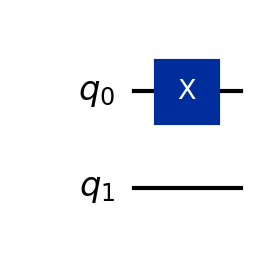

- **Qiskit:** The upper wire is $q_0$. $X$ is applied to $q_0$, and the state is $q_0 = 1, q_1 = 0$. The ket notation is $\vert q_1\, q_0\rangle = \vert 01\rangle$.
- **Notes:** The upper wire is $q_1$. $X$ is applied to $q_1$, and the state is $q_1 = 1, q_2 = 0$. The ket notation is $\vert q_1\, q_2\rangle = \vert 10\rangle$.

The ket notations are different, $\vert 01\rangle$ versus $\vert 10\rangle$, but the circuit is identical, and the physics — "measuring the upper wire always gives 1" — is the same.

In [ ]:
# Circuit applying X to the upper wire (just one)
qc = QuantumCircuit(2)
qc.x(0)  # In Qiskit, the upper wire is q_0

# Check the state vector
sv = Statevector.from_instruction(qc)

print("State vector array:", np.array(sv).round(4))
print()
for i, amp in enumerate(sv):
    if abs(amp) > 1e-10:
        q0 = i & 1       # Qiskit's q_0 (upper wire)
        q1 = (i >> 1) & 1 # Qiskit's q_1 (lower wire)
        print(f"  Array index {i} (binary {i:02b})")
        print(f"    Qiskit: q_0={q0}, q_1={q1} → ket |q_1 q_0⟩ = |{q1}{q0}⟩")
        print(f"    Notes:  q_1={q0}, q_2={q1} → ket |q_1 q_2⟩ = |{q0}{q1}⟩")

print()
print("→ Qiskit writes |01⟩, notes write |10⟩, but it's the same state of the same circuit.")
print("   The physics — 'measuring the upper wire always gives 1' — is unchanged.")

### Example 2: Bell State Generation

Apply $H$ to the upper wire and CNOT from top to bottom. We read **this single circuit** under both conventions.

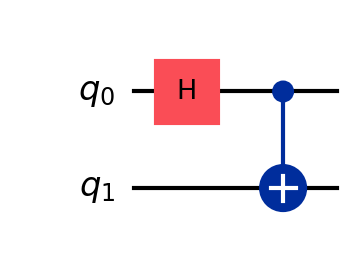

- **Qiskit:** $H$ on $q_0$, $\text{CNOT}_{01}$ → ket $(\vert 00\rangle + \vert 11\rangle)/\sqrt{2}$ ($q_0$ on the right)
- **Notes:** $H$ on $q_1$, $\text{CNOT}_{12}$ → ket $(\vert 00\rangle + \vert 11\rangle)/\sqrt{2}$ ($q_1$ on the left)

In this case, the ket notation is the same $\vert 00\rangle + \vert 11\rangle$. This is not a coincidence — $\vert 00\rangle$ and $\vert 11\rangle$ remain the same string when the bits are reversed.

What matters is not whether the ket notations look identical, but whether the physics — "measurement results of the two wires always agree" — is the same.

In [ ]:
# Bell state circuit (just one)
qc_bell = QuantumCircuit(2)
qc_bell.h(0)      # H on the upper wire
qc_bell.cx(0, 1)  # CNOT from top to bottom

# Check the state vector
sv_bell = Statevector.from_instruction(qc_bell)

print("State vector array:", np.array(sv_bell).round(4))
print()
print("Non-zero amplitudes:")
for i, amp in enumerate(sv_bell):
    if abs(amp) > 1e-10:
        q0 = i & 1
        q1 = (i >> 1) & 1
        print(f"  Array index {i} (binary {i:02b})")
        print(f"    Qiskit: q_0={q0}, q_1={q1} → ket |{q1}{q0}⟩")
        print(f"    Notes:  q_1={q0}, q_2={q1} → ket |{q0}{q1}⟩")

print()
print("→ In both conventions, this can be written as |00⟩ + |11⟩ (the strings happen to coincide here).")
print("   The physically important fact is that 'measurement results of the two wires always agree',")
print("   which does not depend on labeling.")

## 4. Summary

| Item | Notes body (textbook convention) | Notebook / Circuit diagram (Qiskit) |
|---|---|---|
| Index | 1-indexed ($q_1, q_2, \ldots$) | 0-indexed ($q_0, q_1, \ldots$) |
| Ket notation | $\vert q_1\, q_2\, q_3\rangle$ (numerical order, from left) | $\vert q_2\, q_1\, q_0\rangle$ ($q_0$ on the right) |
| Circuit diagram labels | Generated by Qiskit, so $q_0, q_1, \ldots$ (differs from body) | $q_0, q_1, \ldots$ |
| Circuit diagram connections | Same | Same |
| Physical results | Same | Same |

As long as labels are relabeled consistently, the physical results do not change. What matters is only the connections of "which gate is applied to which wire and which wire is measured." Whether to call it $q_0$ or $q_1$ does not affect the result.

In subsequent notebooks (02, 03, 05, 06), you can focus on the operation of the circuit without worrying about this point.

## 5. Caution: When Interpreting Measurement Results as Integers

Relabeling does not change the physics, but **when reading measurement results as integers, the bit ordering convention must be aligned**.

In Quantum Phase Estimation (QPE, Note 05), each wire controls a different power of $U_a$:

- The topmost wire ($q_0$) controls $U_a^{2^{n-1}}$ → **most significant bit (MSB)**
- The bottommost wire ($q_{n-1}$) controls $U_a^1$ → **least significant bit (LSB)**

After measurement, to recover the phase as $\varphi = \tilde{s}/2^n$, the measurement value of each wire must be assigned to the correct bit position to assemble the integer $\tilde{s}$.

For example, with $n = 3$, when only the upper wire is 1 (and the rest are 0):

| Reading method | Integer value | Correct? |
|---|---|---|
| Read from MSB textbook-style: $100_2$ | $\tilde{s} = 4$ | Correct |
| Use Qiskit array index as is: index = 1 | $\tilde{s} = 1$ | **Wrong** |

In Qiskit's little-endian convention, $q_0$ is the LSB (least significant bit), but in this circuit, $q_0$ carries the MSB (most significant bit). Therefore, using the array index directly as the integer $\tilde{s}$ reverses the bit order and yields an incorrect phase.

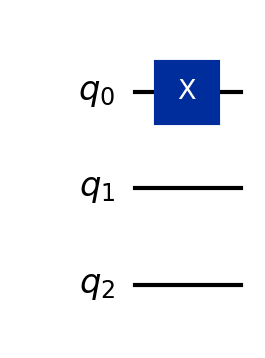

In [ ]:
# Example of integer interpretation in QPE (n=3 bits)
# Create a state where only the upper wire (q_0) is 1, the rest are 0

n = 3
qc_qpe = QuantumCircuit(n)
qc_qpe.x(0)  # Set the upper wire (q_0) to 1

# Verify the difference in integer interpretation via the state vector
sv_qpe = Statevector.from_instruction(qc_qpe)

for i, amp in enumerate(sv_qpe):
    if abs(amp) > 1e-10:
        bits = [(i >> k) & 1 for k in range(n)]
        
        # Method 1: Use the array index as is (wrong)
        s_wrong = i
        
        # Method 2: Convert correctly with q_0 as MSB
        s_correct = sum(bits[k] * 2 ** (n - 1 - k) for k in range(n))
        
        print(f"Array index: {i} (binary {i:03b})")
        print(f"Wire values: q_0={bits[0]}, q_1={bits[1]}, q_2={bits[2]}")
        print()
        print(f"  ✗ Use index as s:                s = |{i:03b}⟩ = {s_wrong} → φ = {s_wrong}/{2**n} = {s_wrong/2**n}")
        print(f"  ✓ Convert with q_0 as MSB:        s = |{bits[0]}{bits[1]}{bits[2]}⟩ = {s_correct} → φ = {s_correct}/{2**n} = {s_correct/2**n}")
        print()
        print(f"In QPE circuits, q_0 controls U^{2**(n-1)}, so q_0 is the MSB.")
        print(f"To get the correct integer value, the bit order must be explicitly converted.")

In other words, the physical state of "which wire is 0 and which wire is 1" is the same regardless of labeling, but **assembling those measurement values into a single integer** requires a bit ordering convention. The code in notebooks 05 and 06 performs this conversion explicitly.

The physics does not change. But the integer interpretation depends on the convention — keeping this distinction in mind is important.